In [265]:
import os
import gc 
import torch
#import gradio as gr
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision.transforms as transforms


# Initialize model with 4 out labels
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 4)
print(model)

# Define the device
try:
    
    device = "mps"
    model = model.to(device)

except:
    print(("Abort training on CPU..."))
    

# Set the directory paths
directories = ["./Data/brain_tumor_4variants/Training",
               "./Data/brain_tumor_4variants2/Training"]

# Initialize empty lists to store the data
data = []

# Define the label mappings for the second dataset
label_mapping = {
    "no_tumor": 0,
    "notumor": 0,
    "glioma_tumor": 1,
    "glioma": 1,
    "meningioma_tumor": 2,
    "meningioma": 2,
    "pituitary_tumor": 3,
    "pituitary": 3
}

# Iterate through the directories
for directory in directories:
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            # Get a list of all .jpg files in the subdirectory
            file_list = [file for file in os.listdir(
                subdir_path) if file.endswith(".jpg")]
            
            # Append the data to data
            data.extend([(os.path.join(subdir_path, file),
                          label_mapping[subdir]) for file in file_list])

# Create the datasets as pandas DataFrames
dataset = pd.DataFrame(
    data, columns=["Image_Path", "Label"])

class BrainTumorDataset(Dataset):
    def __init__(self, data_frame, transform=None):
        """
        Args:
            data_frame (pd.DataFrame): DataFrame with image paths and labels.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.data_frame = data_frame
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the item to fetch.
        
        Returns:
            tuple: (image, label) where image is the transformed image and label is the corresponding label.
        """
        img_path = self.data_frame.iloc[idx, 0]
        image = Image.open(img_path).convert("RGB")  # Convert to RGB
        label = self.data_frame.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        return image, label

def get_normalize_vals(img_path):
    """Return the mean and std for a chosen image in order to use Normalize in the transforms method of the dataset."""
    img = Image.open(img_path)
    transform = transforms.Compose([transforms.ToTensor()])
    img_tensor = transform(img)
    means = torch.mean(img_tensor, dim=[1,2])
    stds = torch.std(img_tensor, dim=[1,2])
    return means, stds

path = "./Data/brain_tumor_4variants/Training/glioma_tumor/gg (1).jpg"
m, s = get_normalize_vals(path)

# Define the transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(
        mean=m, std=s),
    transforms.Lambda(lambda x: torch.clamp(x,0,1))
])

btd1 = BrainTumorDataset(data_frame=dataset, transform=transform)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [266]:
# make dataloader test
directory = ["./Data/brain_tumor_4variants/Testing"]

# Initialize empty lists to store the data
data = []

# Define the label mappings for the second dataset
label_mapping = {
    "no_tumor": 0,
    "notumor": 0,
    "glioma_tumor": 1,
    "glioma": 1,
    "meningioma_tumor": 2,
    "meningioma": 2,
    "pituitary_tumor": 3,
    "pituitary": 3
}

# Iterate through the directories
for directory in directories:
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            # Get a list of all .jpg files in the subdirectory
            file_list = [file for file in os.listdir(
                subdir_path) if file.endswith(".jpg")]
            
            # Append the data to data
            data.extend([(os.path.join(subdir_path, file),
                          label_mapping[subdir]) for file in file_list])

# Create the datasets as pandas DataFrames
dataset = pd.DataFrame(
    data, columns=["Image_Path", "Label"])

# Create the datasets using the DataFrames created earlier
btd2 = BrainTumorDataset(data_frame=dataset, transform=transform)

In [267]:
# make dataloader validator
directory = ["./Data/brain_tumor_4variants/Testing"]

# Initialize empty lists to store the data
data = []

# Define the label mappings for the second dataset
label_mapping = {
    "no_tumor": 0,
    "notumor": 0,
    "glioma_tumor": 1,
    "glioma": 1,
    "meningioma_tumor": 2,
    "meningioma": 2,
    "pituitary_tumor": 3,
    "pituitary": 3
}

# Iterate through the directories
for directory in directories:
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            # Get a list of all .jpg files in the subdirectory
            file_list = [file for file in os.listdir(
                subdir_path) if file.endswith(".jpg")]
            
            # Append the data to data
            data.extend([(os.path.join(subdir_path, file),
                          label_mapping[subdir]) for file in file_list])

# Create the datasets as pandas DataFrames
dataset = pd.DataFrame(
    data, columns=["Image_Path", "Label"])

# Create the datasets using the DataFrames created earlier
btd3 = BrainTumorDataset(data_frame=dataset, transform=transform)

Epoch 1/15, Training Loss: 1.062984965104596
Epoch 1/15, Accuracy: 65.15963644838033%
Epoch 2/15, Training Loss: 0.7779328635855678
Epoch 2/15, Accuracy: 63.038918666977395%
Epoch 3/15, Training Loss: 0.6654157401460697
Epoch 3/15, Accuracy: 71.70822652062456%
Early stopping triggered. Best model was from epoch 2
Loaded best model from epoch 2


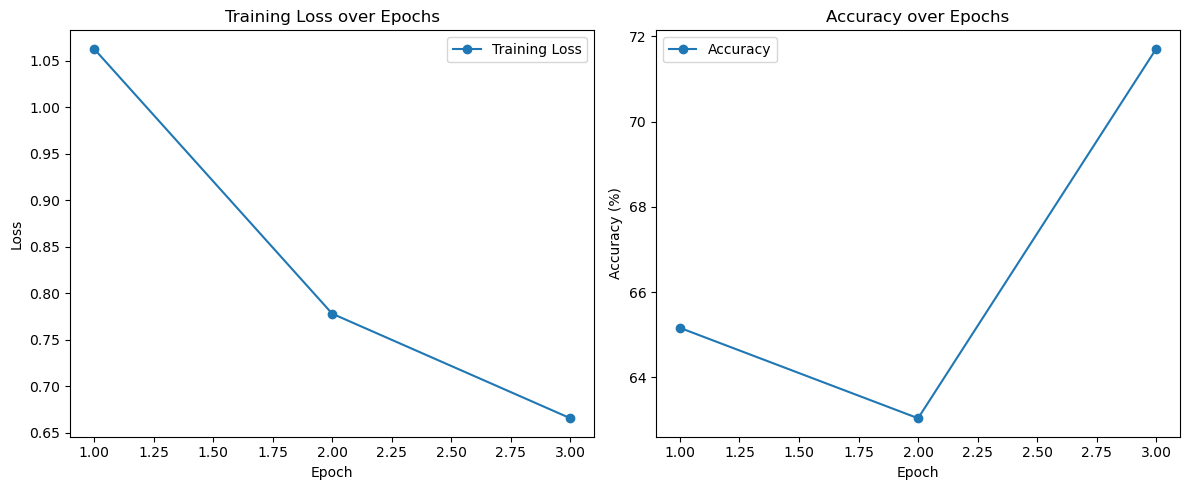

In [268]:
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import SGD
import matplotlib.pyplot as plt

device = "mps"

# training pipeline 
trainloader = DataLoader(batch_size=32, shuffle=True, dataset=btd1)
testloader = DataLoader(batch_size=32, shuffle=True, dataset=btd2)

train_losses = []
accuracies = []
best_accuracy = 81.33
epochs_without_improvement = 0
early_stopping_patience = 3
epochs = 15
criterion = CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=0.001, momentum=0.7)
model = model.to("mps")

for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss}")

    # Testing phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    accuracies.append(accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy}%")

    # Model checkpointing
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_without_improvement = 0
        print(f"New best model saved at epoch {epoch+1}")
    else:
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= early_stopping_patience:
        print(
            f"Early stopping triggered. Best model was from epoch {best_epoch+1}")
        break
    
    # Load the best model after training
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch+1}")

# Plotting the performance
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses,
            marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(accuracies) + 1),
            accuracies, marker='o', label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [191]:
# when happy save to ...
d = date.today()
dt = str(d.month) + str(d.year)
torch.save(model.state_dict(), f"./Models/resnet18/{model.__class__.__name__}_mri__{dt}.pth")

In [195]:
# load model
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load("./Models/resnet18/resnet_mri_062024.pth", weights_only=True))

<All keys matched successfully>

In [264]:
import gc 

gc.collect()

45813

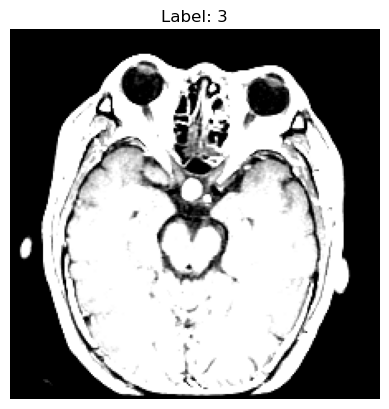

Probabilities: tensor([[0.1356, 0.1287, 0.4133, 0.3224]])
Prediction: 2
Label: 3


In [ ]:


device = "cpu"
model = model.to(device)

def eval_perform(model, dataset):
    # Set the model to evaluation mode
    model.eval()

    # Pick a random image from the dataset
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]
    # Add batch dimension and move to device
    image = image.unsqueeze(0).to(device)

    # Run the model on the image
    with torch.no_grad():
        logits = model(image)

    # Calculate probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Display the image
    image_np = image.squeeze(0).cpu().numpy().transpose((1, 2, 0))
    
    plt.imshow(image_np)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

    return probabilities, label

probabilities, label = eval_perform(model, btd3)
print("Probabilities:", probabilities)
_, prediction = torch.max(probabilities.data, 1)
print("Prediction:", int(prediction))
print("Label:", label)